In [2]:
import sys
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
from accelerate import Accelerator
import pandas as pd
import itertools
import time
import matplotlib.pyplot as plt
import numpy as np
import glob


# Add src/ directory to Python path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../src")))

/Users/saamnazem/M2_stuff/M2_venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/saamnazem/M2_stuff/M2_venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from qwen import load_qwen
from processor import load_and_preprocess
from lora import LoRALinear
from data import compute_convergence_speed, process_sequences

### Grid Search Training of LR vs LoRA Rank

In [ ]:
# Force everything to CPU
device = torch.device("cpu")

# Define Hyperparameter Grid
learning_rates = [1e-5, 5e-5, 1e-4]
lora_ranks = [2, 4, 8]
num_epochs = 500 


results = []

# Start Grid Search
for lr, lora_rank in itertools.product(learning_rates, lora_ranks):
    print(f"\n🔹 Running Experiment: LR={lr}, LoRA Rank={lora_rank}")

    # Load model and move to CPU
    model, tokenizer = load_qwen()
    model.to(device)

    # Apply LoRA to Query & Value Projection Layers
    for layer in model.model.layers:
        layer.self_attn.q_proj = LoRALinear(layer.self_attn.q_proj, r=lora_rank)
        layer.self_attn.v_proj = LoRALinear(layer.self_attn.v_proj, r=lora_rank)

    # Load dataset
    train_texts, val_texts = load_and_preprocess("coursework/lotka_volterra_data.h5", num_systems=100, time_steps=10, fraction=0.8)

    # Convert tokenized text into tensors
    max_ctx_length = 256  # Default fixed context length for now
    train_input_ids = process_sequences(train_texts, tokenizer, max_ctx_length)
    val_input_ids = process_sequences(val_texts, tokenizer, max_ctx_length)

    # Prepare DataLoaders
    batch_size = 2
    train_dataset = TensorDataset(train_input_ids)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(val_input_ids)
    val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

    # Optimizer (only trainable LoRA parameters)
    optimizer = torch.optim.Adam((p for p in model.parameters() if p.requires_grad), lr=lr)

    # Use Accelerator for efficient training
    accelerator = Accelerator()
    model, optimizer, train_loader = accelerator.prepare(model, optimizer, train_loader)

    for param in model.parameters():
        param.data = param.data.to("cpu")
        if param.grad is not None:
            param.grad.data = param.grad.data.to("cpu")
    for buffer in model.buffers():
        buffer.data = buffer.data.to("cpu")

    train_losses = []
    val_losses = []
    eval_interval = 100  # Evaluate validation loss every 100 steps
    start_time = time.time()

    # Train LoRA Model
    model.train()
    steps = 0
    while steps < num_epochs:
        progress_bar = tqdm(train_loader, desc=f"LR={lr}, Rank={lora_rank}, Step {steps}")
        for (batch,) in progress_bar:
            optimizer.zero_grad()
            batch = batch.to(device, dtype=torch.long)

            outputs = model(batch, labels=batch)
            loss = outputs.loss
            accelerator.backward(loss)
            optimizer.step()
            steps += 1

            train_losses.append(loss.item())
            progress_bar.set_postfix(loss=loss.item())

            if steps % eval_interval == 0:
                model.eval()
                val_loss_total = 0
                with torch.no_grad():
                    for (val_batch,) in val_loader:
                        val_batch = val_batch.to(device, dtype=torch.long)
                        val_outputs = model(val_batch, labels=val_batch)
                        val_loss_total += val_outputs.loss.item()
                avg_val_loss = val_loss_total / len(val_loader)
                val_losses.append(avg_val_loss)
                print(f"Step {steps}: Validation Loss = {avg_val_loss}")
                model.train()

            if steps >= num_epochs:
                break

    # Save Results
    elapsed_time = time.time() - start_time
    result_entry = {
        "learning_rate": lr,
        "lora_rank": lora_rank,
        "final_train_loss": train_losses[-1],
        "final_val_loss": val_losses[-1] if val_losses else None,
        "time_taken_sec": elapsed_time,
    }
    results.append(result_entry)

    # Save Train & Validation Losses to CSV
    pd.DataFrame({"train_loss": train_losses}).to_csv(f"csv/train_loss_lr{lr}_rank{lora_rank}.csv", index=False)
    pd.DataFrame({"val_loss": val_losses}).to_csv(f"csv/val_loss_lr{lr}_rank{lora_rank}.csv", index=False)

    print(f"\n🔹 Finished Experiment: LR={lr}, Rank={lora_rank}")
    print(f"   Time Taken: {elapsed_time:.2f} sec")
    print(f"   Final Train Loss: {train_losses[-1]:.5f}")
    print(f"   Final Validation Loss: {val_losses[-1] if val_losses else 'N/A'}")

# Save Final Results Table
pd.DataFrame(results).to_csv("csv/grid_search_results_lr_rank.csv", index=False)
print("\nGrid Search Complete! All results saved.")

### Plots

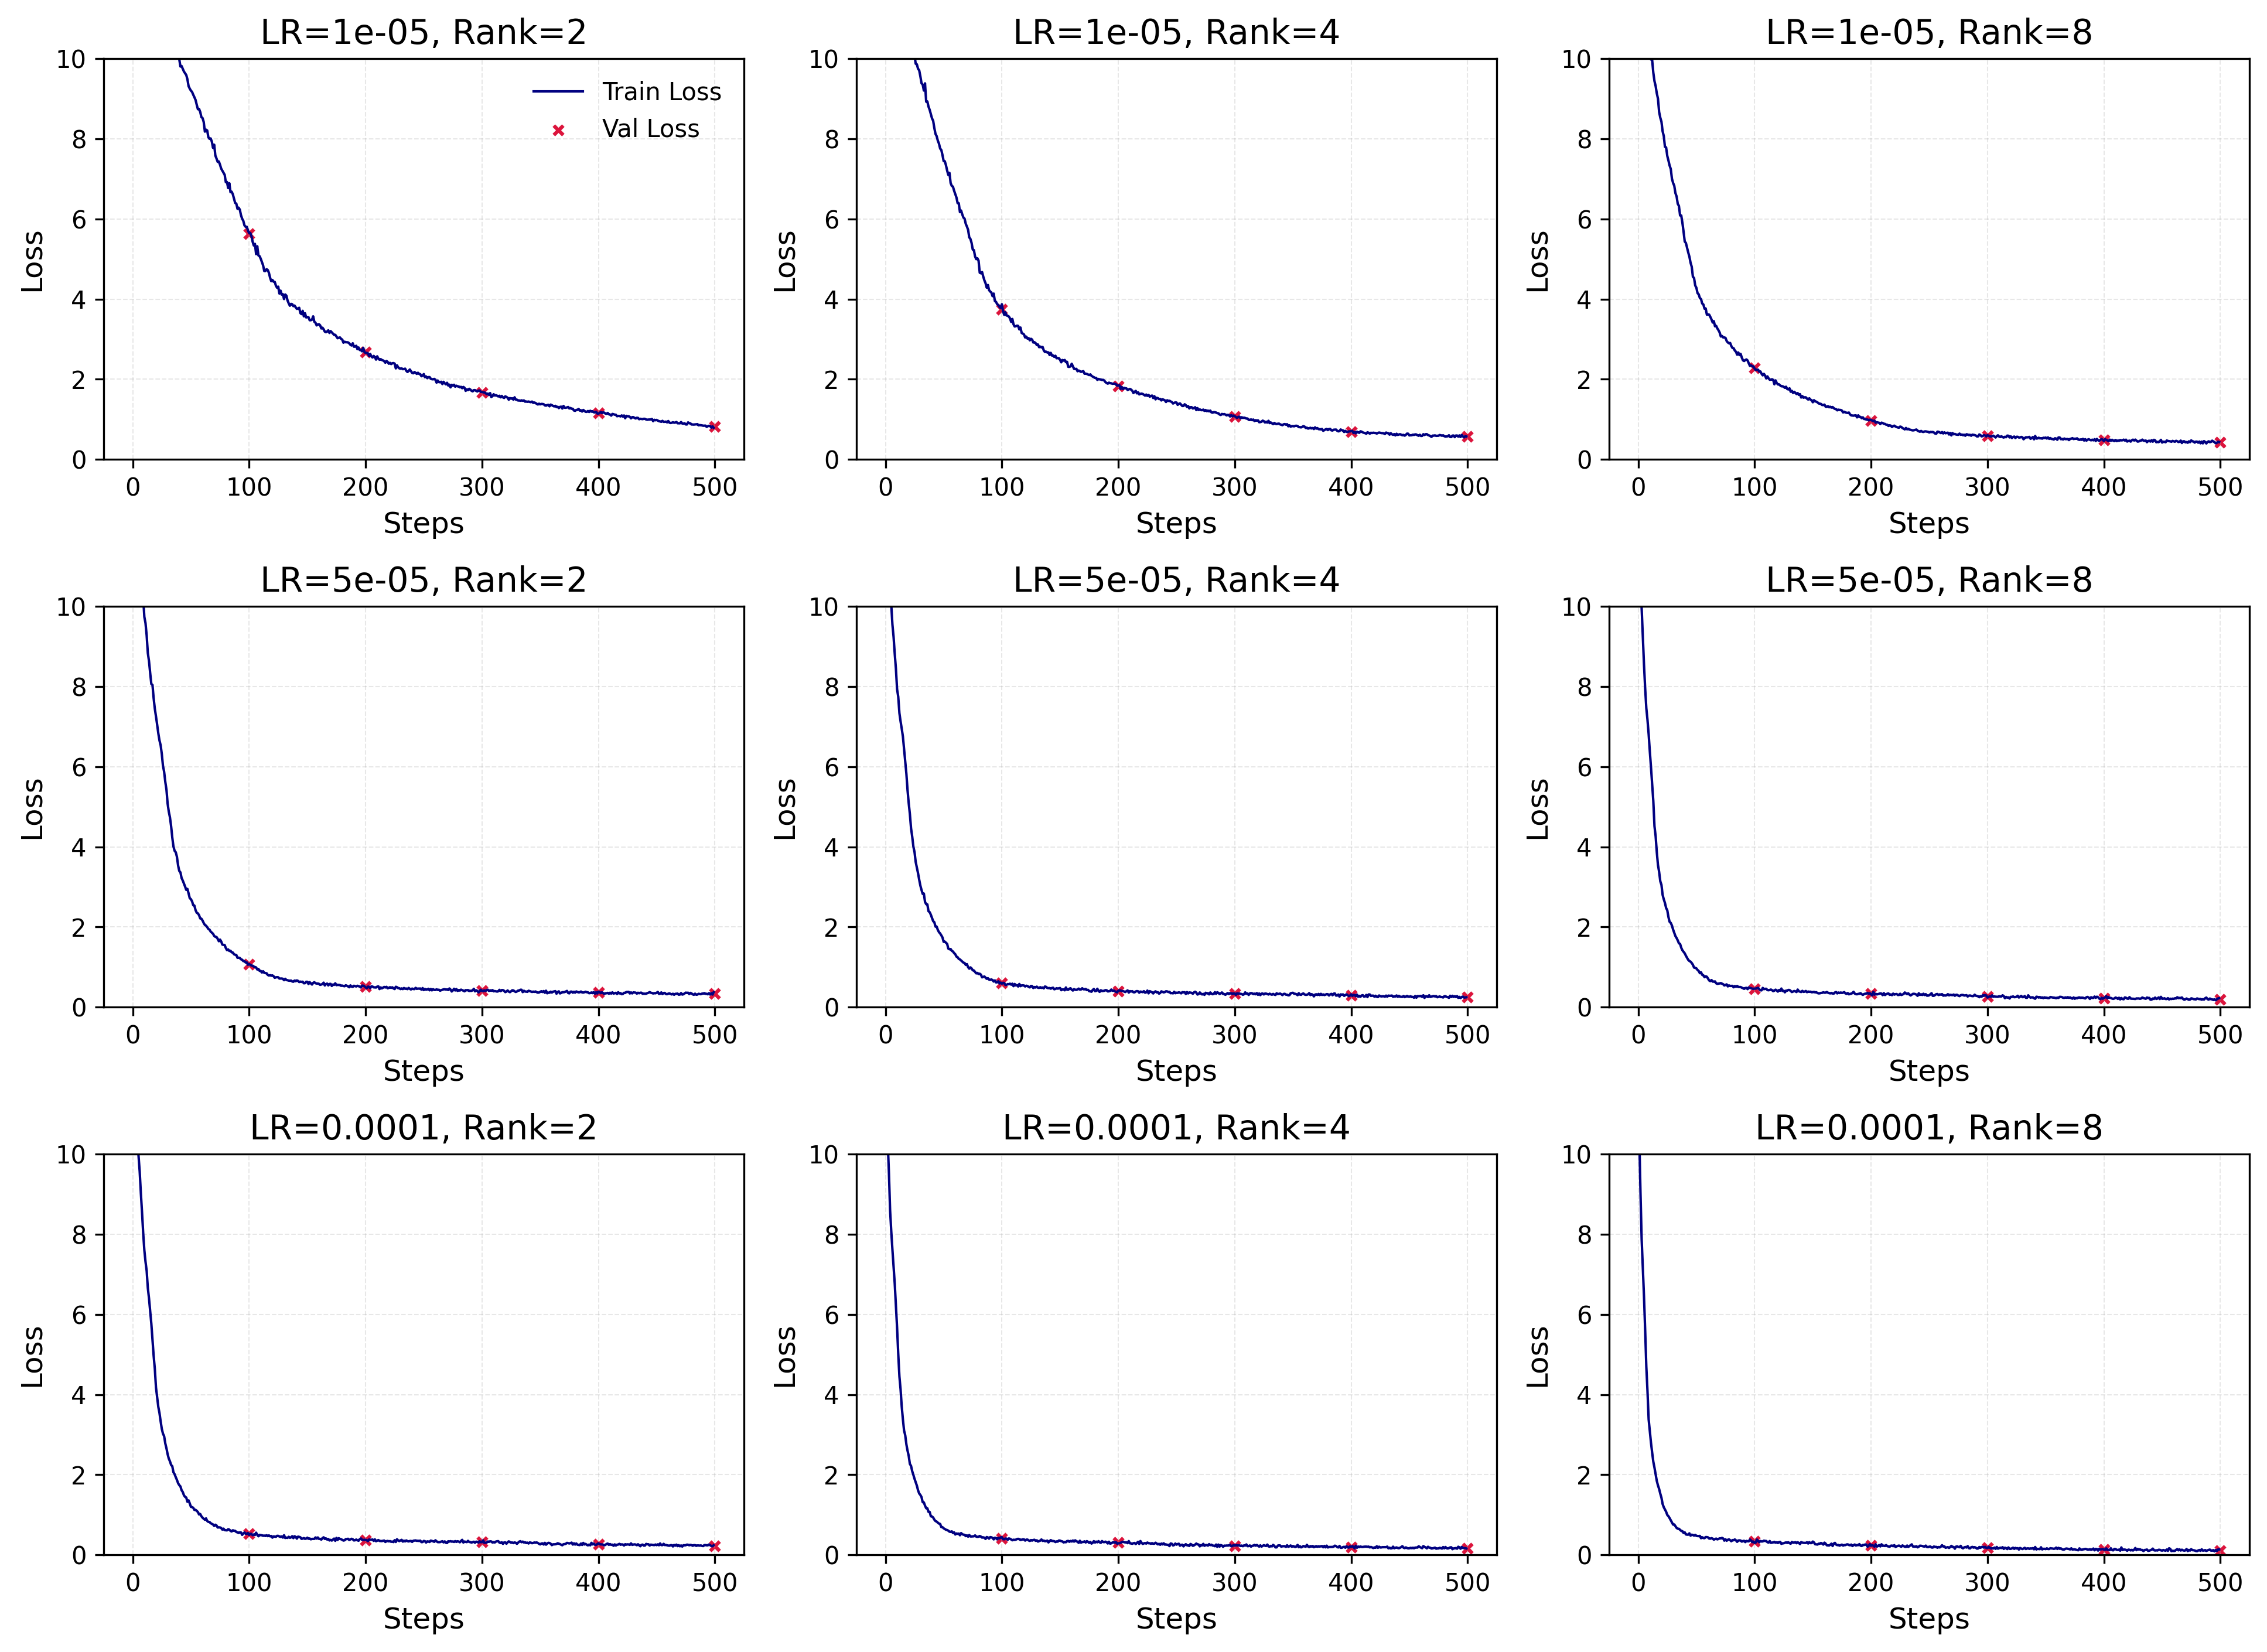

In [ ]:
# Define the grid search values
learning_rates = [1e-5, 5e-5, 1e-4]
lora_ranks = [2, 4, 8]

fig, axes = plt.subplots(len(learning_rates), len(lora_ranks), figsize=(13, 10), dpi=300)
# fig.suptitle("LoRA Grid Search: Train & Validation Loss", fontsize=16)

eval_interval = 100

for i, (lr, rank) in enumerate(itertools.product(learning_rates, lora_ranks)):
    row, col = divmod(i, len(lora_ranks))
    ax = axes[row, col]

    train_file = f"../csv/train_loss_lr{lr}_rank{rank}.csv"
    val_file = f"../csv/val_loss_lr{lr}_rank{rank}.csv"

    if os.path.exists(train_file) and os.path.exists(val_file):
        train_loss = pd.read_csv(train_file)["train_loss"]
        val_loss = pd.read_csv(val_file)["val_loss"]
        val_steps = list(range(eval_interval, eval_interval * len(val_loss) + 1, eval_interval))

        # Train curve
        ax.plot(train_loss, color="navy", lw=1, label="Train Loss")

        # Val points
        ax.scatter(val_steps, val_loss, color="crimson", marker="x", s=15, label="Val Loss")

        # Style
        ax.set_title(f"LR={lr}, Rank={rank}", fontsize=14)
        ax.set_ylim(0, 10)
        ax.set_xticks([0, 100, 200, 300, 400, 500])
        ax.set_xlabel("Steps", fontsize=12)
        ax.set_ylabel("Loss", fontsize=12)
        ax.tick_params(axis='both', labelsize=10)
        ax.grid(alpha=0.3, linestyle='--', linewidth=0.5)

        if row == 0 and col == 0:
            ax.legend(fontsize=10, frameon=False)
    else:
        ax.text(0.5, 0.5, "Missing Data", ha="center", va="center", fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Model ../csv/train_loss_lr0.0001_rank8.csv: Converged at step 101
Model ../csv/train_loss_lr1e-05_rank8.csv: Converged at step 292
Model ../csv/train_loss_lr5e-05_rank8.csv: Converged at step 153
Model ../csv/train_loss_lr1e-05_rank2.csv: Converged at step 500
Model ../csv/train_loss_lr5e-05_rank2.csv: Converged at step 256
Model ../csv/train_loss_lr1e-05_rank4.csv: Converged at step 439
Model ../csv/train_loss_lr5e-05_rank4.csv: Converged at step 176
Model ../csv/train_loss_lr0.0001_rank2.csv: Converged at step 147
Model ../csv/train_loss_lr0.0001_rank4.csv: Converged at step 132


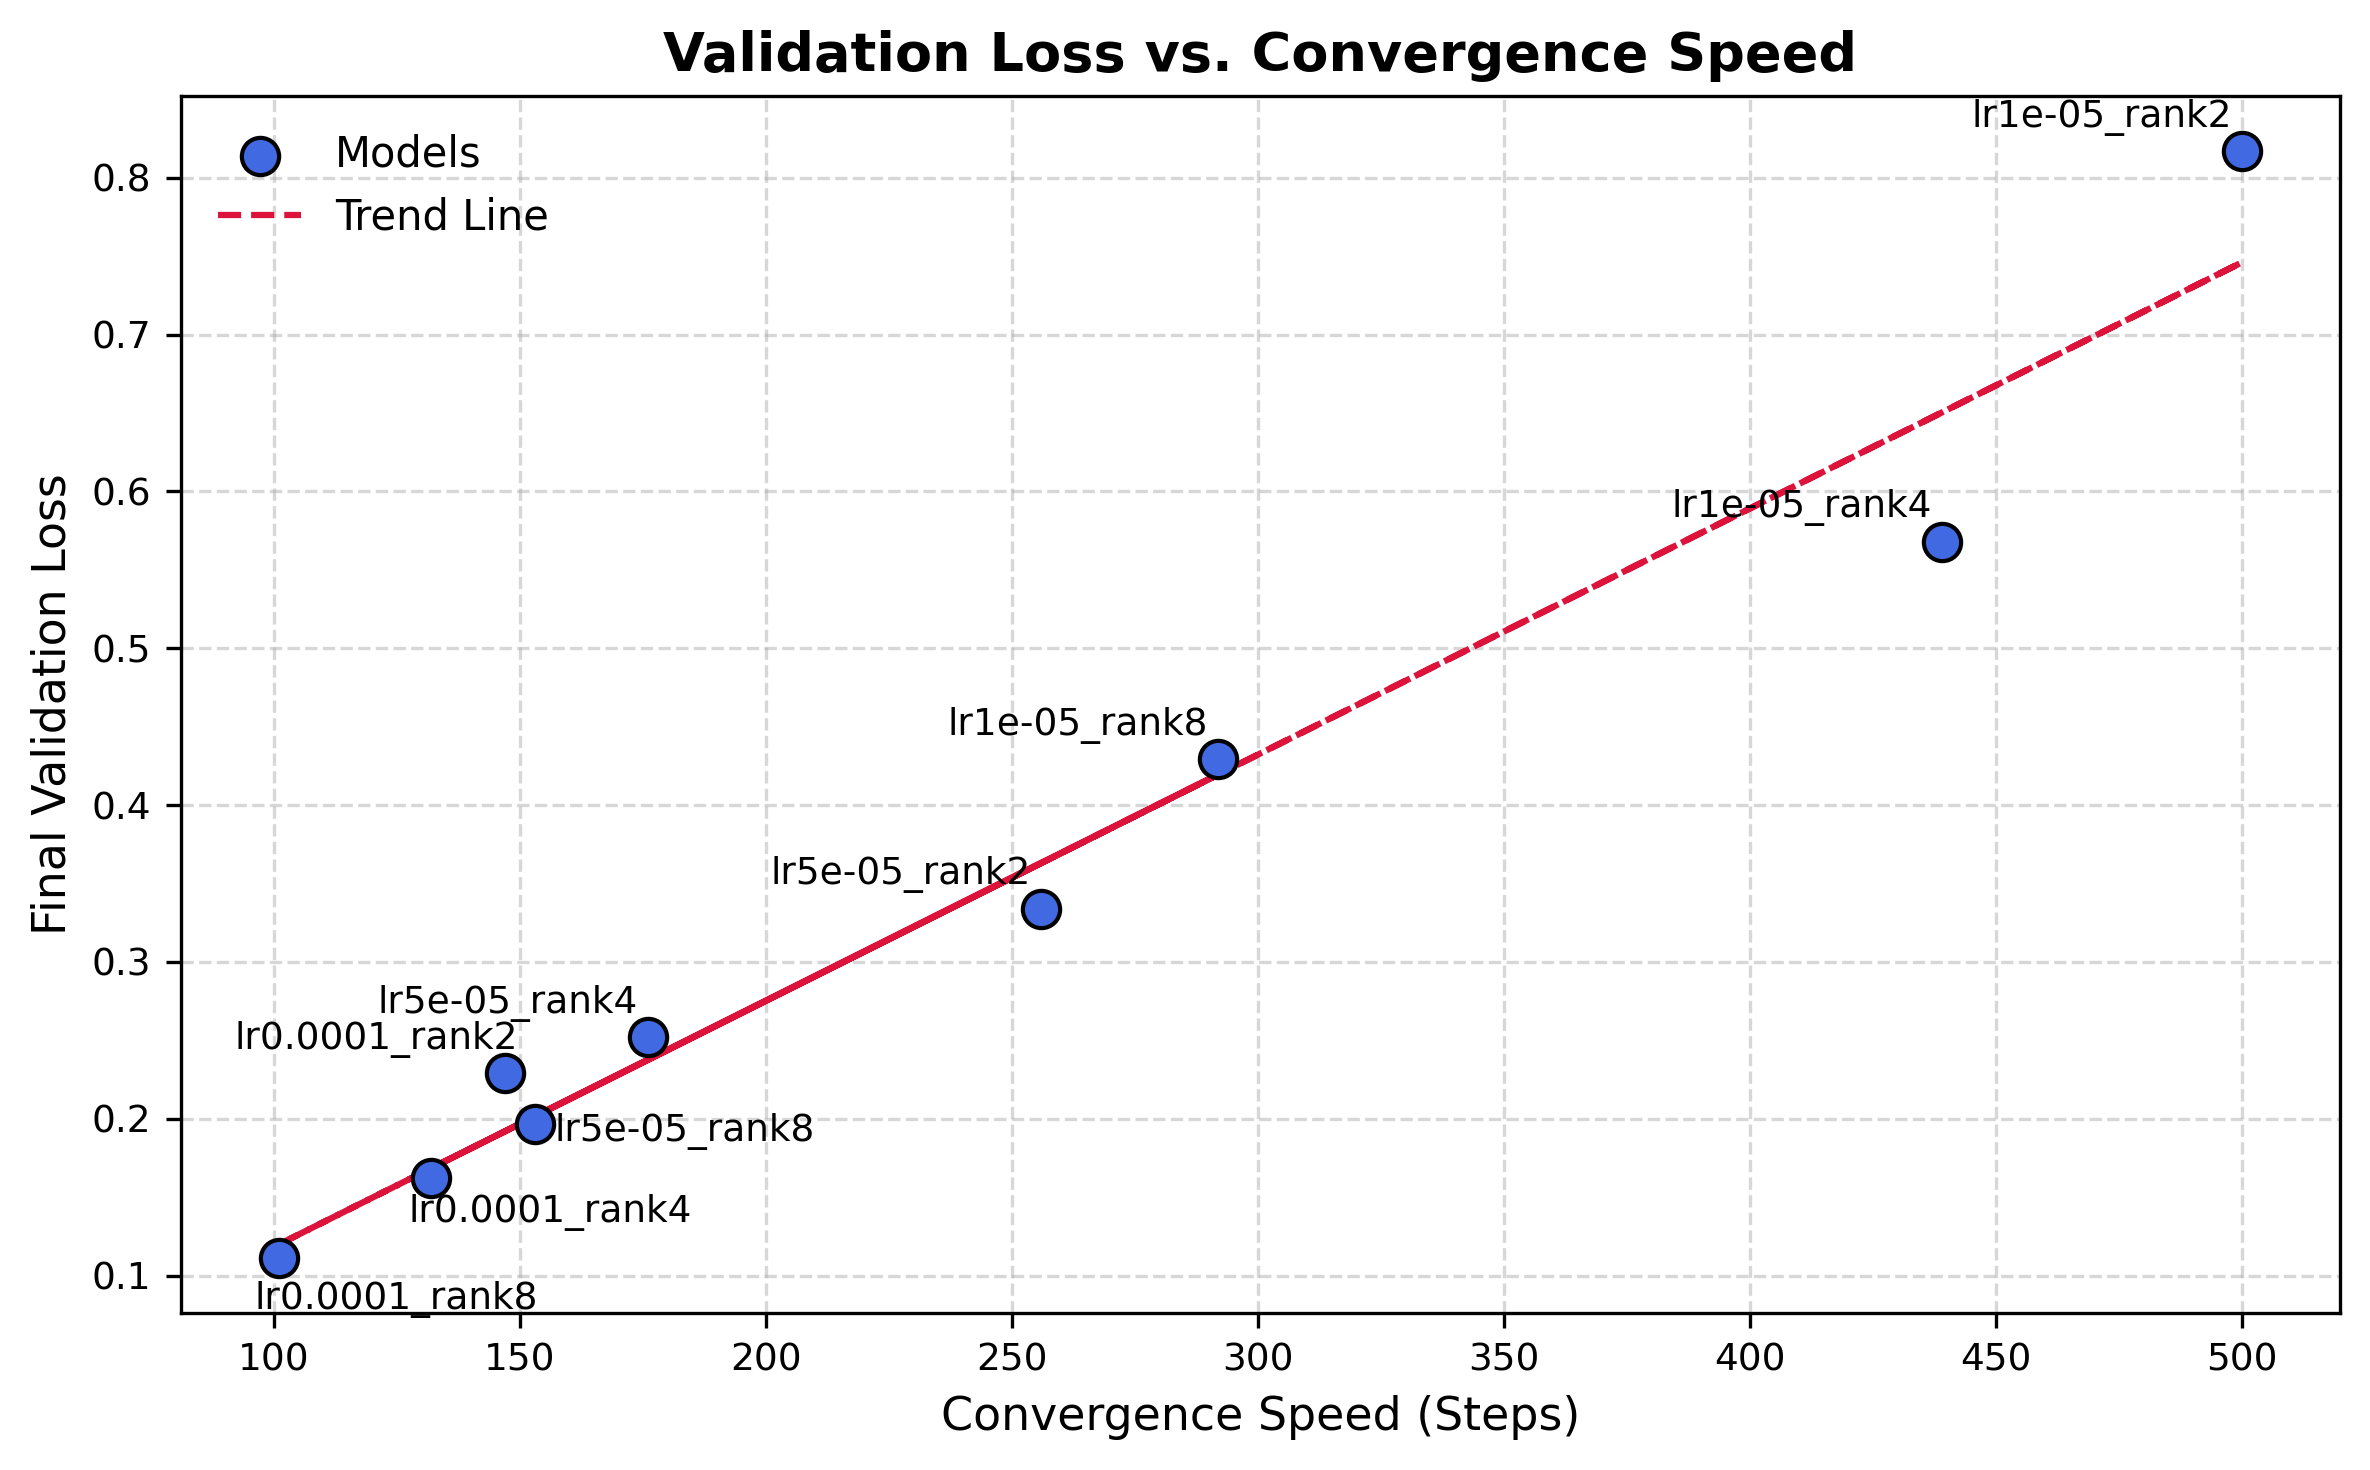

In [ ]:
# Load all train loss CSVs and compute convergence speed
train_loss_files = glob.glob("../csv/train_loss_lr*.csv")
convergence_speeds = {f: compute_convergence_speed(f) for f in train_loss_files}

# Print results
for model, conv_speed in convergence_speeds.items():
    print(f"Model {model}: Converged at step {conv_speed}")

# Load validation losses (last entry)
val_loss_files = glob.glob("../csv/val_loss_lr*.csv")
val_losses = {f: pd.read_csv(f)["val_loss"].values[-1] for f in val_loss_files}


train_loss_files = glob.glob("../csv/train_loss_lr*.csv")
convergence_speeds = {f: compute_convergence_speed(f) for f in train_loss_files}


# Extract clean model names
def clean_name(f): return f.split("/")[-1].replace("train_loss_", "").replace("val_loss_", "").replace(".csv", "")

# Create aligned lists
common_models = set(map(clean_name, train_loss_files)).intersection(set(map(clean_name, val_loss_files)))

conv_speeds = [convergence_speeds[f"../csv/train_loss_{m}.csv"] for m in common_models]
val_losses_plot = [val_losses[f"../csv/val_loss_{m}.csv"] for m in common_models]

plt.figure(figsize=(8, 5), dpi=300)

# Plot points
plt.scatter(conv_speeds, val_losses_plot, color='royalblue', edgecolors='black',
            marker='o', s=80, label="Models", zorder=3)

# Annotate: top-left for all, bottom-right for `lr0.0001_rank4`
for i, model in enumerate(common_models):
    x, y = conv_speeds[i], val_losses_plot[i]
    
    if model == "lr0.0001_rank4":
        ha, va = "right", "top"
        offset_x, offset_y = 53, -0.01
    elif model == "lr0.0001_rank8":
        ha, va = "left", "top"
        offset_x, offset_y = -5, -0.015
    elif model == "lr5e-05_rank8":
        ha, va = "right", "bottom"
        offset_x, offset_y = 57, -0.016
    else:
        ha, va = "left", "bottom"
        offset_x, offset_y = -55, 0.01
    
    plt.annotate(model, (x + offset_x, y + offset_y),
                 fontsize=9, ha=ha, va=va, color='black')

# Trend line
z = np.polyfit(conv_speeds, val_losses_plot, 1)
p = np.poly1d(z)
plt.plot(conv_speeds, p(conv_speeds), linestyle="--", color="crimson", linewidth=1.5, label="Trend Line", zorder=2)

# Axis, grid, legend
plt.xlabel("Convergence Speed (Steps)", fontsize=11)
plt.ylabel("Final Validation Loss", fontsize=11)
plt.title("Validation Loss vs. Convergence Speed", fontsize=13, fontweight="semibold")
plt.grid(True, linestyle="--", alpha=0.5, zorder=0)
plt.legend(frameon=False, fontsize=10)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.show()
